In [1]:
from pathlib import Path

BASE_DIR = Path("e6_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"
MODEL_DIR = BASE_DIR / "models"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, MODEL_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e6_artifacts/logs
/content/e6_artifacts/tables
/content/e6_artifacts/figures
/content/e6_artifacts/reports
/content/e6_artifacts/models


In [2]:
import pandas as pd

TRAIN_PATH = "train_final.csv"
VAL_PATH = "val_final.csv"
TEST_PATH = "test_final.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

display(train_df.head())
display(val_df.head())
display(test_df.head())

train_df shape: (7957, 3)
val_df shape: (885, 3)
test_df shape: (2211, 3)


,text,label,id
0,@YELLEZ @WylsacomRed Почему бы просто не купит...,neutral,1215652526319722501
1,"посмотрите кто-нибудь ""импровизацию""..\r\nя хо...",positive,1341141182093668352
2,@robodeacon зашел сфоткаться с кастом тени и к...,neutral,1234077503993581569
3,Моя оформа: /меняется на чёрно-белую/\r\n\r\nМ...,neutral,1326075120465702912
4,сижу в такси рядом ползает паук няшка,positive,1276191130535821315


,text,label,id
0,Да его надо скачать хотя бы потому что там ест...,neutral,1283293286799638529
1,@suckerforhome блин..сочувствую.,negative,1269992603543572482
2,@stayloveswoojin Дыня,neutral,1285265175898140674
3,@polinapingvina @Teimir1 личный опыт субъектив...,neutral,1299732127307755523
4,@deadjane666 Подъезжаешь к ней на фиолетовом з...,positive,1237272095647764480


,text,label,id
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209
3,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432
4,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041


In [3]:
SEED = 42

X_train = train_df["text"].copy()
y_train = train_df["label"].copy()

X_val = val_df["text"].copy()
y_val = val_df["label"].copy()

X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7957,)
y_train: (7957,)
X_val: (885,)
y_val: (885,)
X_test: (2211,)
y_test: (2211,)


In [4]:
import json

BERT_MODEL_PATH = "rubert_tiny2_sentiment_model_tuned"  # замени путь, если нужно

E6_CONFIG = {
    "experiment": "E6 hybrid ensemble classical + BERT",
    "dataset": "RuSentiTweet",
    "train_file": TRAIN_PATH,
    "val_file": VAL_PATH,
    "test_file": TEST_PATH,
    "seed": SEED,
    "classical_model": {
        "model": "SGDClassifier hinge",
        "calibration": "CalibratedClassifierCV",
        "representation": {
            "type": "TfidfVectorizer",
            "lowercase": True,
            "analyzer": "char_wb",
            "ngram_range": (3, 5),
            "min_df": 2,
            "max_df": 0.95
        }
    },
    "bert_model_path": BERT_MODEL_PATH,
    "hybrid_methods": [
        "soft_voting_equal",
        "soft_voting_weighted_by_val"
    ]
}

with open(LOG_DIR / "e6_config.json", "w", encoding="utf-8") as f:
    json.dump(E6_CONFIG, f, ensure_ascii=False, indent=4)

print("Saved:", LOG_DIR / "e6_config.json")

Saved: e6_artifacts/logs/e6_config.json


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_val_char = char_vectorizer.transform(X_val)
X_test_char = char_vectorizer.transform(X_test)

print("X_train_char shape:", X_train_char.shape)
print("X_val_char shape:", X_val_char.shape)
print("X_test_char shape:", X_test_char.shape)

X_train_char shape: (7957, 78069)
X_val_char shape: (885, 78069)
X_test_char shape: (2211, 78069)


In [6]:
import time
import numpy as np

from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [7]:
sgd_base = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

sgd_cal = CalibratedClassifierCV(
    estimator=sgd_base,
    method="sigmoid",
    cv=3
)

start_time_classical = time.time()
sgd_cal.fit(X_train_char, y_train)
train_time_classical = time.time() - start_time_classical

print("Calibrated classical fit time:", round(train_time_classical, 4))

Calibrated classical fit time: 3.1789


In [8]:
proba_classical_val = sgd_cal.predict_proba(X_val_char)
proba_classical_test = sgd_cal.predict_proba(X_test_char)

print("Classical classes:", sgd_cal.classes_)
print(proba_classical_val.shape, proba_classical_test.shape)

Classical classes: ['negative' 'neutral' 'positive']
(885, 3) (2211, 3)


In [9]:
!pip install -q transformers datasets accelerate

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
from pathlib import Path

root = Path("/content/drive/MyDrive")
for p in root.iterdir():
    print(p.name)

Висмут, химия.pptx
Мероприятие.gsite
Colab Notebooks
data8.csv
Беспроводные сети .gdoc
MindSpace Mood Tracker.gform
MindSpace DB.gsheet
Запись экрана 2025-05-30 в 21.09.03.mov
mindspace
ВКР Артем с правками.gdoc
Копия Невзорова_ карта КПЭ_2кв 2025.gsheet
Исследователи отмечают, что стоимость компании является одним из наиболее полных показателей результатов деятельности организации.gdoc
Невзорова_ карта КПЭ_3кв 2025 ПЛАН (1).xlsx
Невзорова_ карта КПЭ_3кв 2025 ПЛАН.xlsx
Карта КПЭ 3 кв Невзорова Количественные.gsheet
Карта КПЭ Невзорова 3 кв Качественные.gsheet
sentiment_practice
Питомцы
NIR dirt (4).gdoc
NIR dirt (3).gdoc
NIR dirt (2).gdoc
NIR dirt (1).gdoc
Как потребители видят бренд «Дядя Ваня»: лояльность, чувствительность к цене и готовность к репозиционированию бренда copy.gform
Как потребители видят бренд «Дядя Ваня»: лояльность, чувствительность к цене и готовность к репозиционированию бренда (Ответы).gsheet
test_google_forms_350_responses.gsheet
Как потребители видят бренд «Дяд

In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
BERT_MODEL_PATH = "/content/drive/MyDrive/rubert_tiny2_sentiment_model_tuned"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_PATH)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_PATH)
bert_model.to(device)
bert_model.eval()

print("BERT loaded successfully")

Device: cpu


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BERT loaded successfully


In [15]:
label_order = ["negative", "neutral", "positive"]
label2id = {label: i for i, label in enumerate(label_order)}
id2label = {i: label for label, i in label2id.items()}

print(label2id)

{'negative': 0, 'neutral': 1, 'positive': 2}


In [16]:
import numpy as np
from torch.nn.functional import softmax

def bert_predict_proba(texts, tokenizer, model, device, max_length=128, batch_size=32):
    all_probs = []

    texts = list(texts)

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            probs = softmax(outputs.logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

    return np.vstack(all_probs)

In [17]:
start_time_bert_inference = time.time()

proba_bert_val = bert_predict_proba(X_val, tokenizer, bert_model, device)
proba_bert_test = bert_predict_proba(X_test, tokenizer, bert_model, device)

bert_inference_time = time.time() - start_time_bert_inference

print("BERT inference time:", round(bert_inference_time, 4))
print(proba_bert_val.shape, proba_bert_test.shape)

BERT inference time: 60.6938
(885, 3) (2211, 3)


In [18]:
label_order = ["negative", "neutral", "positive"]

In [19]:
classical_class_order = list(sgd_cal.classes_)
print("Classical order:", classical_class_order)
print("Target order:", label_order)

classical_reorder_indices = [classical_class_order.index(lbl) for lbl in label_order]

proba_classical_val = proba_classical_val[:, classical_reorder_indices]
proba_classical_test = proba_classical_test[:, classical_reorder_indices]

print("Reordered classical probabilities.")

Classical order: ['negative', 'neutral', 'positive']
Target order: ['negative', 'neutral', 'positive']
Reordered classical probabilities.


In [20]:
def evaluate_from_proba(
    model_name,
    ensemble_type,
    y_true,
    proba,
    report_filename,
    extra_time_sec=0.0
):
    pred_ids = np.argmax(proba, axis=1)
    y_pred = np.array([label_order[i] for i in pred_ids])

    acc = accuracy_score(y_true, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_true, y_pred, average="macro")

    report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)

    with open(REPORT_DIR / report_filename, "w", encoding="utf-8") as f:
        f.write(report_text)

    result = {
        "model": model_name,
        "ensemble_type": ensemble_type,
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "extra_time_sec": round(extra_time_sec, 4),
        "seed": SEED
    }

    return result, y_pred, report_text

In [21]:
res_classical_val, y_pred_classical_val, rep_classical_val = evaluate_from_proba(
    model_name="Standalone classical on val",
    ensemble_type="reference_val",
    y_true=y_val,
    proba=proba_classical_val,
    report_filename="classification_report_val_classical.txt",
    extra_time_sec=train_time_classical
)

print(res_classical_val)
print(rep_classical_val)

{'model': 'Standalone classical on val', 'ensemble_type': 'reference_val', 'accuracy': 0.6723, 'precision_weighted': 0.6808, 'recall_weighted': 0.6723, 'weighted_f1': 0.6636, 'macro_f1': 0.6429, 'extra_time_sec': 3.1789, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.7150    0.5417    0.6164       264
     neutral     0.6485    0.8318    0.7288       428
    positive     0.7059    0.4974    0.5836       193

    accuracy                         0.6723       885
   macro avg     0.6898    0.6236    0.6429       885
weighted avg     0.6808    0.6723    0.6636       885



In [22]:
res_bert_val, y_pred_bert_val, rep_bert_val = evaluate_from_proba(
    model_name="Standalone BERT on val",
    ensemble_type="reference_val",
    y_true=y_val,
    proba=proba_bert_val,
    report_filename="classification_report_val_bert.txt",
    extra_time_sec=bert_inference_time
)

print(res_bert_val)
print(rep_bert_val)

{'model': 'Standalone BERT on val', 'ensemble_type': 'reference_val', 'accuracy': 0.6949, 'precision_weighted': 0.694, 'recall_weighted': 0.6949, 'weighted_f1': 0.6943, 'macro_f1': 0.6801, 'extra_time_sec': 60.6938, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6962    0.6856    0.6908       264
     neutral     0.7205    0.7407    0.7304       428
    positive     0.6324    0.6062    0.6190       193

    accuracy                         0.6949       885
   macro avg     0.6830    0.6775    0.6801       885
weighted avg     0.6940    0.6949    0.6943       885



In [23]:
val_weight_classical = res_classical_val["weighted_f1"]
val_weight_bert = res_bert_val["weighted_f1"]

raw_weights = np.array([val_weight_classical, val_weight_bert], dtype=float)
weights = raw_weights / raw_weights.sum()

print("Validation-based raw weights:", raw_weights)
print("Validation-based normalized weights:", weights)

Validation-based raw weights: [0.6636 0.6943]
Validation-based normalized weights: [0.48869578 0.51130422]


In [24]:
e6_results = []

hybrid_equal_test = 0.5 * proba_classical_test + 0.5 * proba_bert_test

res_hybrid_equal, y_pred_hybrid_equal, rep_hybrid_equal = evaluate_from_proba(
    model_name="Hybrid ensemble equal",
    ensemble_type="soft_voting_equal",
    y_true=y_test,
    proba=hybrid_equal_test,
    report_filename="classification_report_hybrid_equal.txt",
    extra_time_sec=train_time_classical + bert_inference_time
)

e6_results.append(res_hybrid_equal)

print(res_hybrid_equal)
print(rep_hybrid_equal)

{'model': 'Hybrid ensemble equal', 'ensemble_type': 'soft_voting_equal', 'accuracy': 0.7259, 'precision_weighted': 0.728, 'recall_weighted': 0.7259, 'weighted_f1': 0.7218, 'macro_f1': 0.7053, 'extra_time_sec': 63.8727, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.7049    0.6515    0.6772       660
     neutral     0.7233    0.8371    0.7760      1068
    positive     0.7699    0.5818    0.6627       483

    accuracy                         0.7259      2211
   macro avg     0.7327    0.6901    0.7053      2211
weighted avg     0.7280    0.7259    0.7218      2211



In [25]:
hybrid_weighted_test = (
    weights[0] * proba_classical_test +
    weights[1] * proba_bert_test
)

res_hybrid_weighted, y_pred_hybrid_weighted, rep_hybrid_weighted = evaluate_from_proba(
    model_name="Hybrid ensemble weighted",
    ensemble_type="soft_voting_weighted_by_val",
    y_true=y_test,
    proba=hybrid_weighted_test,
    report_filename="classification_report_hybrid_weighted.txt",
    extra_time_sec=train_time_classical + bert_inference_time
)

e6_results.append(res_hybrid_weighted)

print(res_hybrid_weighted)
print(rep_hybrid_weighted)

{'model': 'Hybrid ensemble weighted', 'ensemble_type': 'soft_voting_weighted_by_val', 'accuracy': 0.7273, 'precision_weighted': 0.7292, 'recall_weighted': 0.7273, 'weighted_f1': 0.7232, 'macro_f1': 0.707, 'extra_time_sec': 63.8727, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.7077    0.6530    0.6793       660
     neutral     0.7245    0.8371    0.7767      1068
    positive     0.7690    0.5859    0.6651       483

    accuracy                         0.7273      2211
   macro avg     0.7337    0.6920    0.7070      2211
weighted avg     0.7292    0.7273    0.7232      2211



In [26]:
res_classical_test, y_pred_classical_test, rep_classical_test = evaluate_from_proba(
    model_name="Standalone classical",
    ensemble_type="reference_test",
    y_true=y_test,
    proba=proba_classical_test,
    report_filename="classification_report_test_classical.txt",
    extra_time_sec=train_time_classical
)

print(res_classical_test)

{'model': 'Standalone classical', 'ensemble_type': 'reference_test', 'accuracy': 0.6762, 'precision_weighted': 0.6804, 'recall_weighted': 0.6762, 'weighted_f1': 0.6668, 'macro_f1': 0.6424, 'extra_time_sec': 3.1789, 'seed': 42}


In [27]:
res_bert_test, y_pred_bert_test, rep_bert_test = evaluate_from_proba(
    model_name="Standalone BERT tuned",
    ensemble_type="reference_test",
    y_true=y_test,
    proba=proba_bert_test,
    report_filename="classification_report_test_bert_tuned.txt",
    extra_time_sec=bert_inference_time
)

print(res_bert_test)

{'model': 'Standalone BERT tuned', 'ensemble_type': 'reference_test', 'accuracy': 0.697, 'precision_weighted': 0.6956, 'recall_weighted': 0.697, 'weighted_f1': 0.6958, 'macro_f1': 0.6808, 'extra_time_sec': 60.6938, 'seed': 42}


In [28]:
e6_results.append(res_classical_test)
e6_results.append(res_bert_test)

In [29]:
e6_results_df = pd.DataFrame(e6_results)
e6_results_df = e6_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(e6_results_df)

,model,ensemble_type,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,extra_time_sec,seed
0,Hybrid ensemble weighted,soft_voting_weighted_by_val,0.7273,0.7292,0.7273,0.7232,0.7070,63.8727,42
1,Hybrid ensemble equal,soft_voting_equal,0.7259,0.7280,0.7259,0.7218,0.7053,63.8727,42
2,Standalone BERT tuned,reference_test,0.6970,0.6956,0.6970,0.6958,0.6808,60.6938,42
3,Standalone classical,reference_test,0.6762,0.6804,0.6762,0.6668,0.6424,3.1789,42


In [30]:
e6_results_df.to_csv(TABLE_DIR / "e6_hybrid_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e6_hybrid_results.csv")

Saved: e6_artifacts/tables/e6_hybrid_results.csv


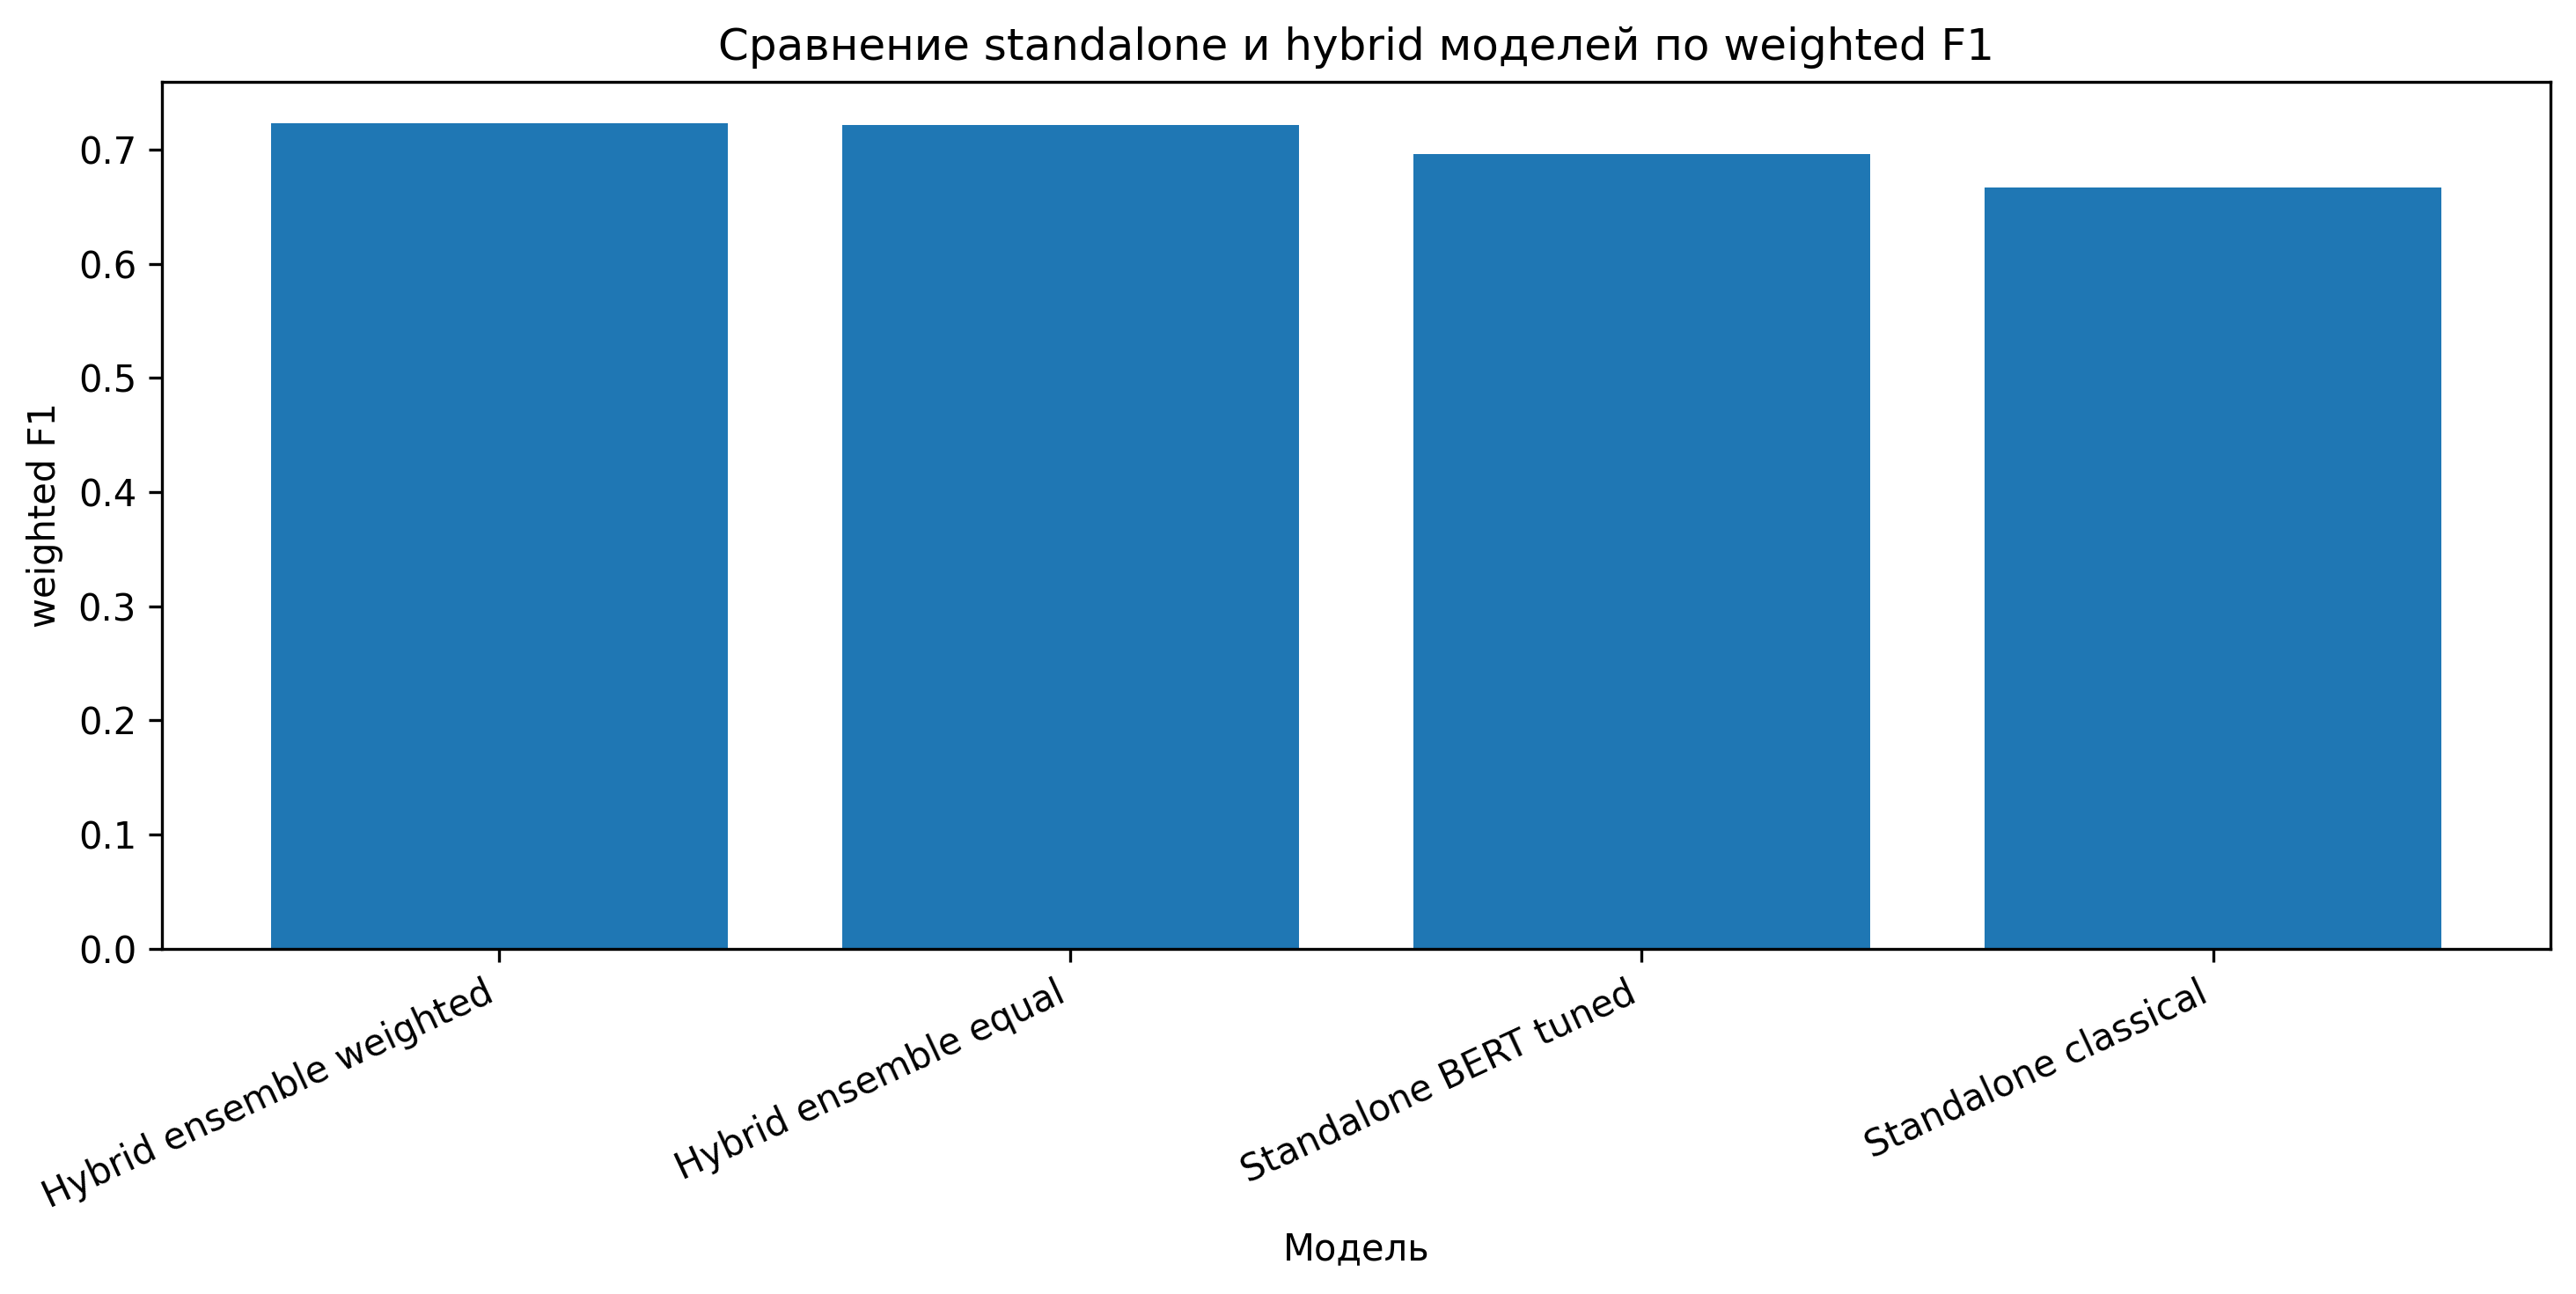

In [31]:
import matplotlib.pyplot as plt

plot_df = e6_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("Сравнение standalone и hybrid моделей по weighted F1")
plt.xlabel("Модель")
plt.ylabel("weighted F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e6_hybrid_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

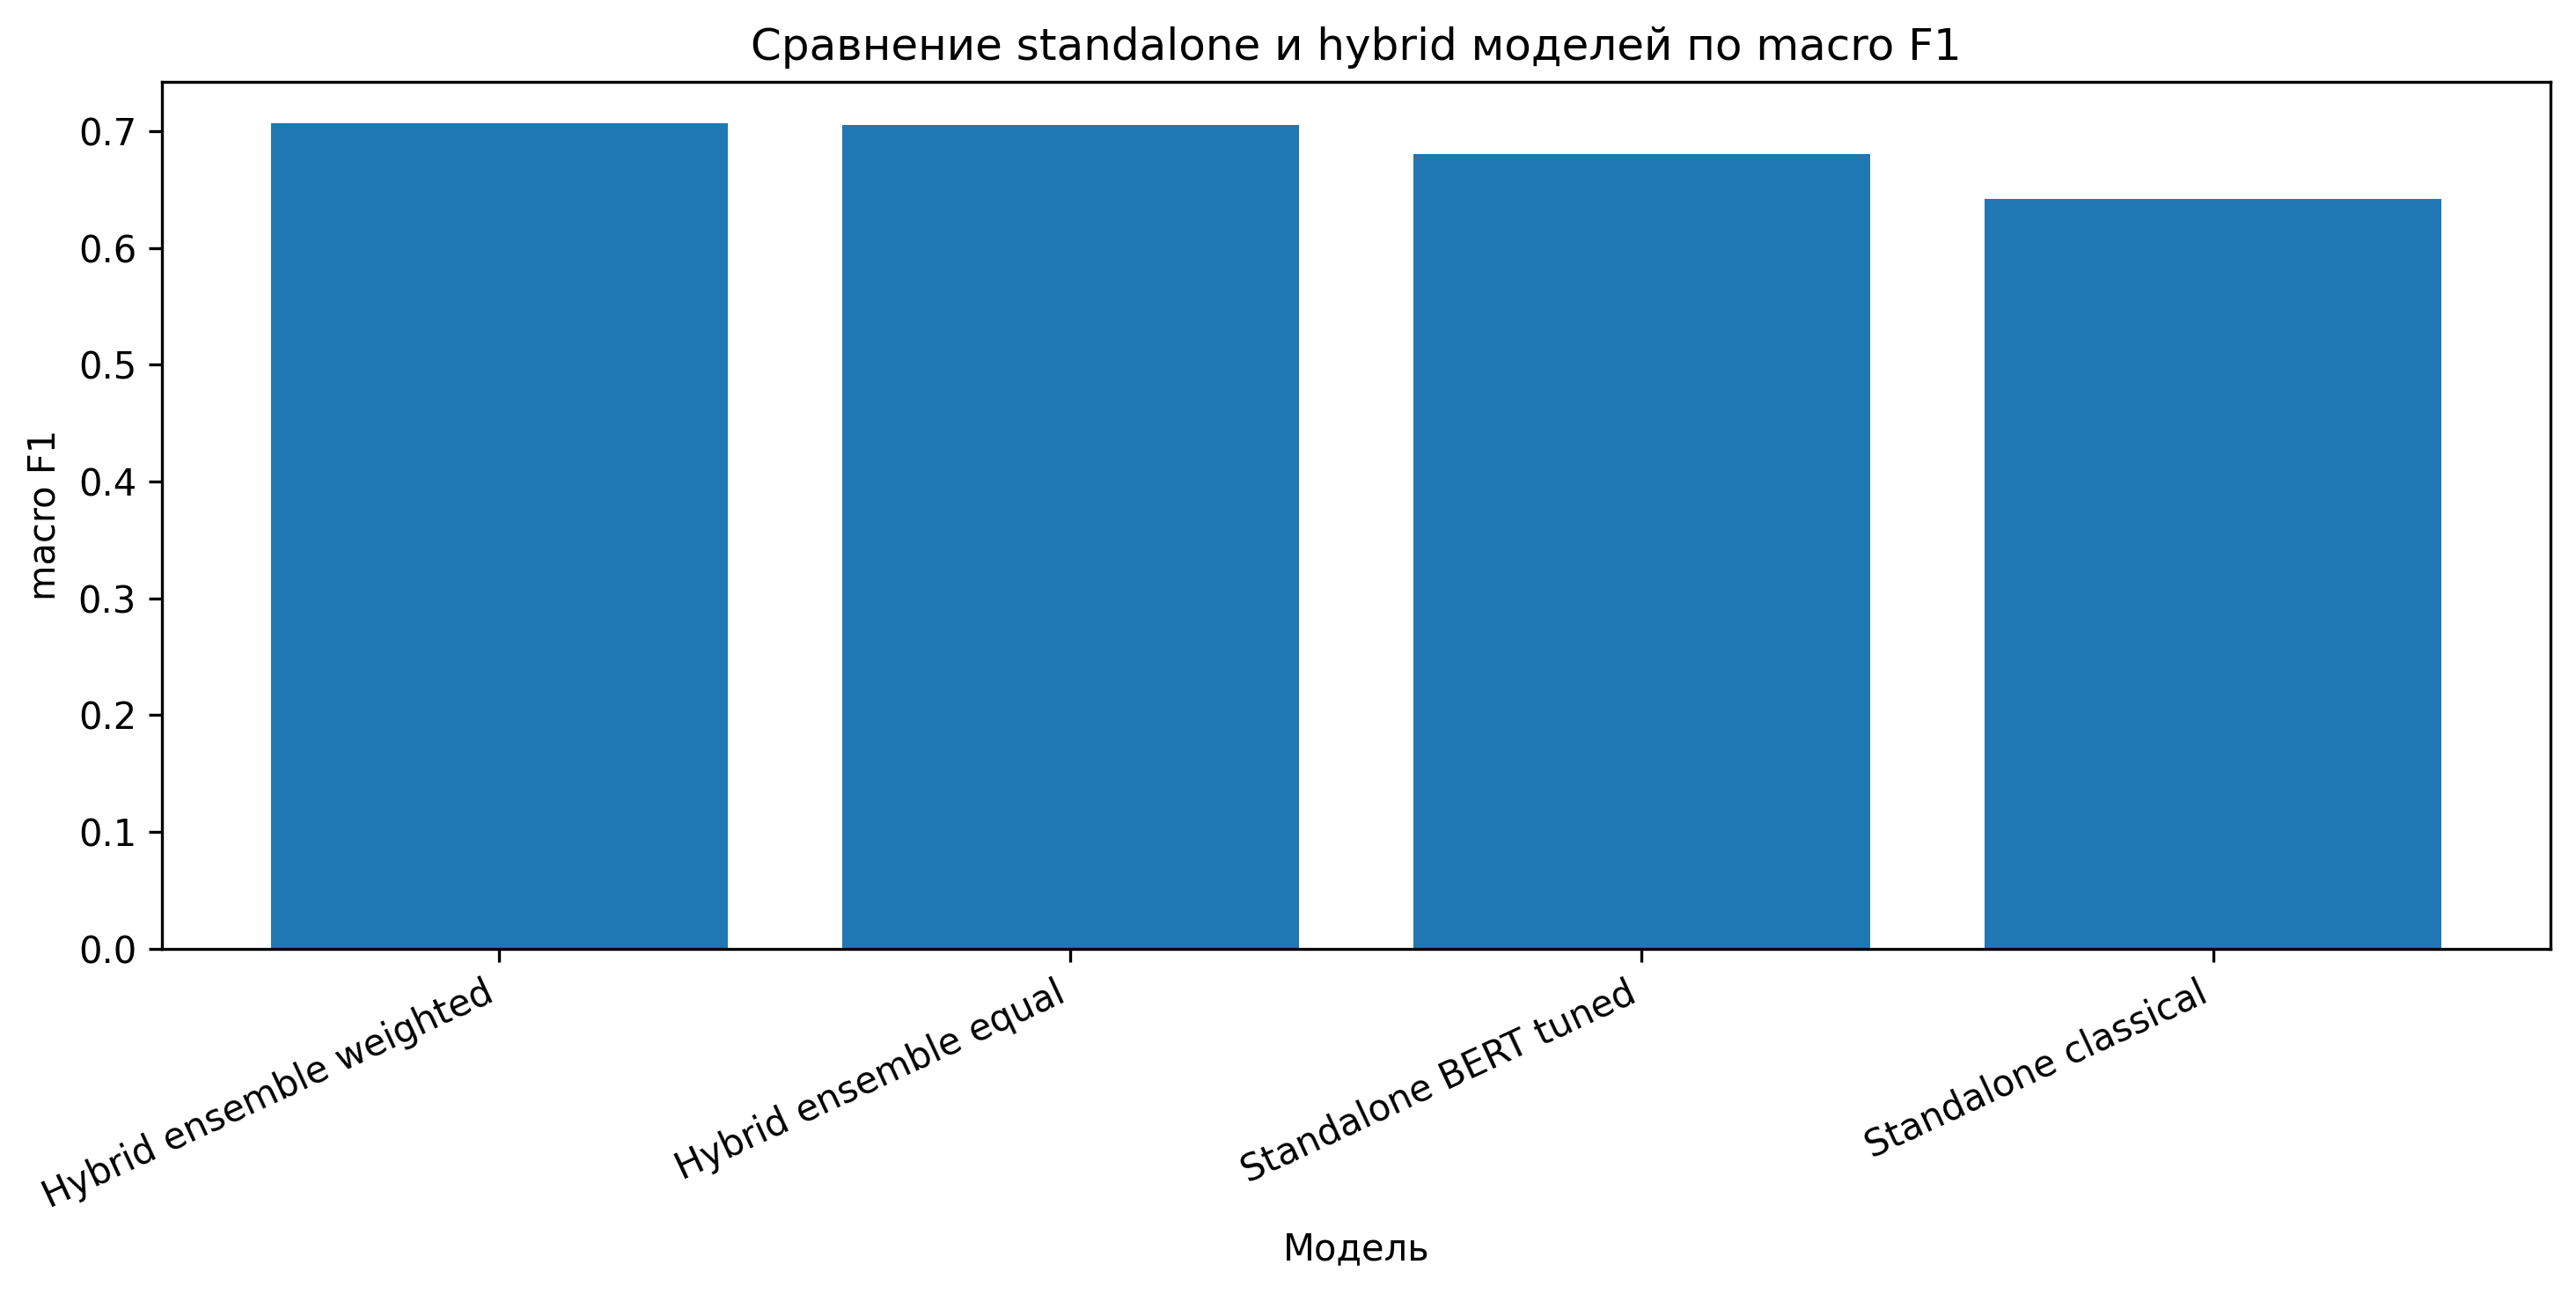

In [32]:
plot_df_macro = e6_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(plot_df_macro["model"], plot_df_macro["macro_f1"])
plt.title("Сравнение standalone и hybrid моделей по macro F1")
plt.xlabel("Модель")
plt.ylabel("macro F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e6_hybrid_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
hybrid_only_df = e6_results_df[e6_results_df["ensemble_type"].isin([
    "soft_voting_equal",
    "soft_voting_weighted_by_val"
])].copy()

best_e6_hybrid_name = hybrid_only_df.iloc[0]["model"]
print("Best E6 hybrid:", best_e6_hybrid_name)

Best E6 hybrid: Hybrid ensemble weighted


In [34]:
predictions_map = {
    "Hybrid ensemble equal": y_pred_hybrid_equal,
    "Hybrid ensemble weighted": y_pred_hybrid_weighted
}

best_e6_pred = predictions_map[best_e6_hybrid_name]

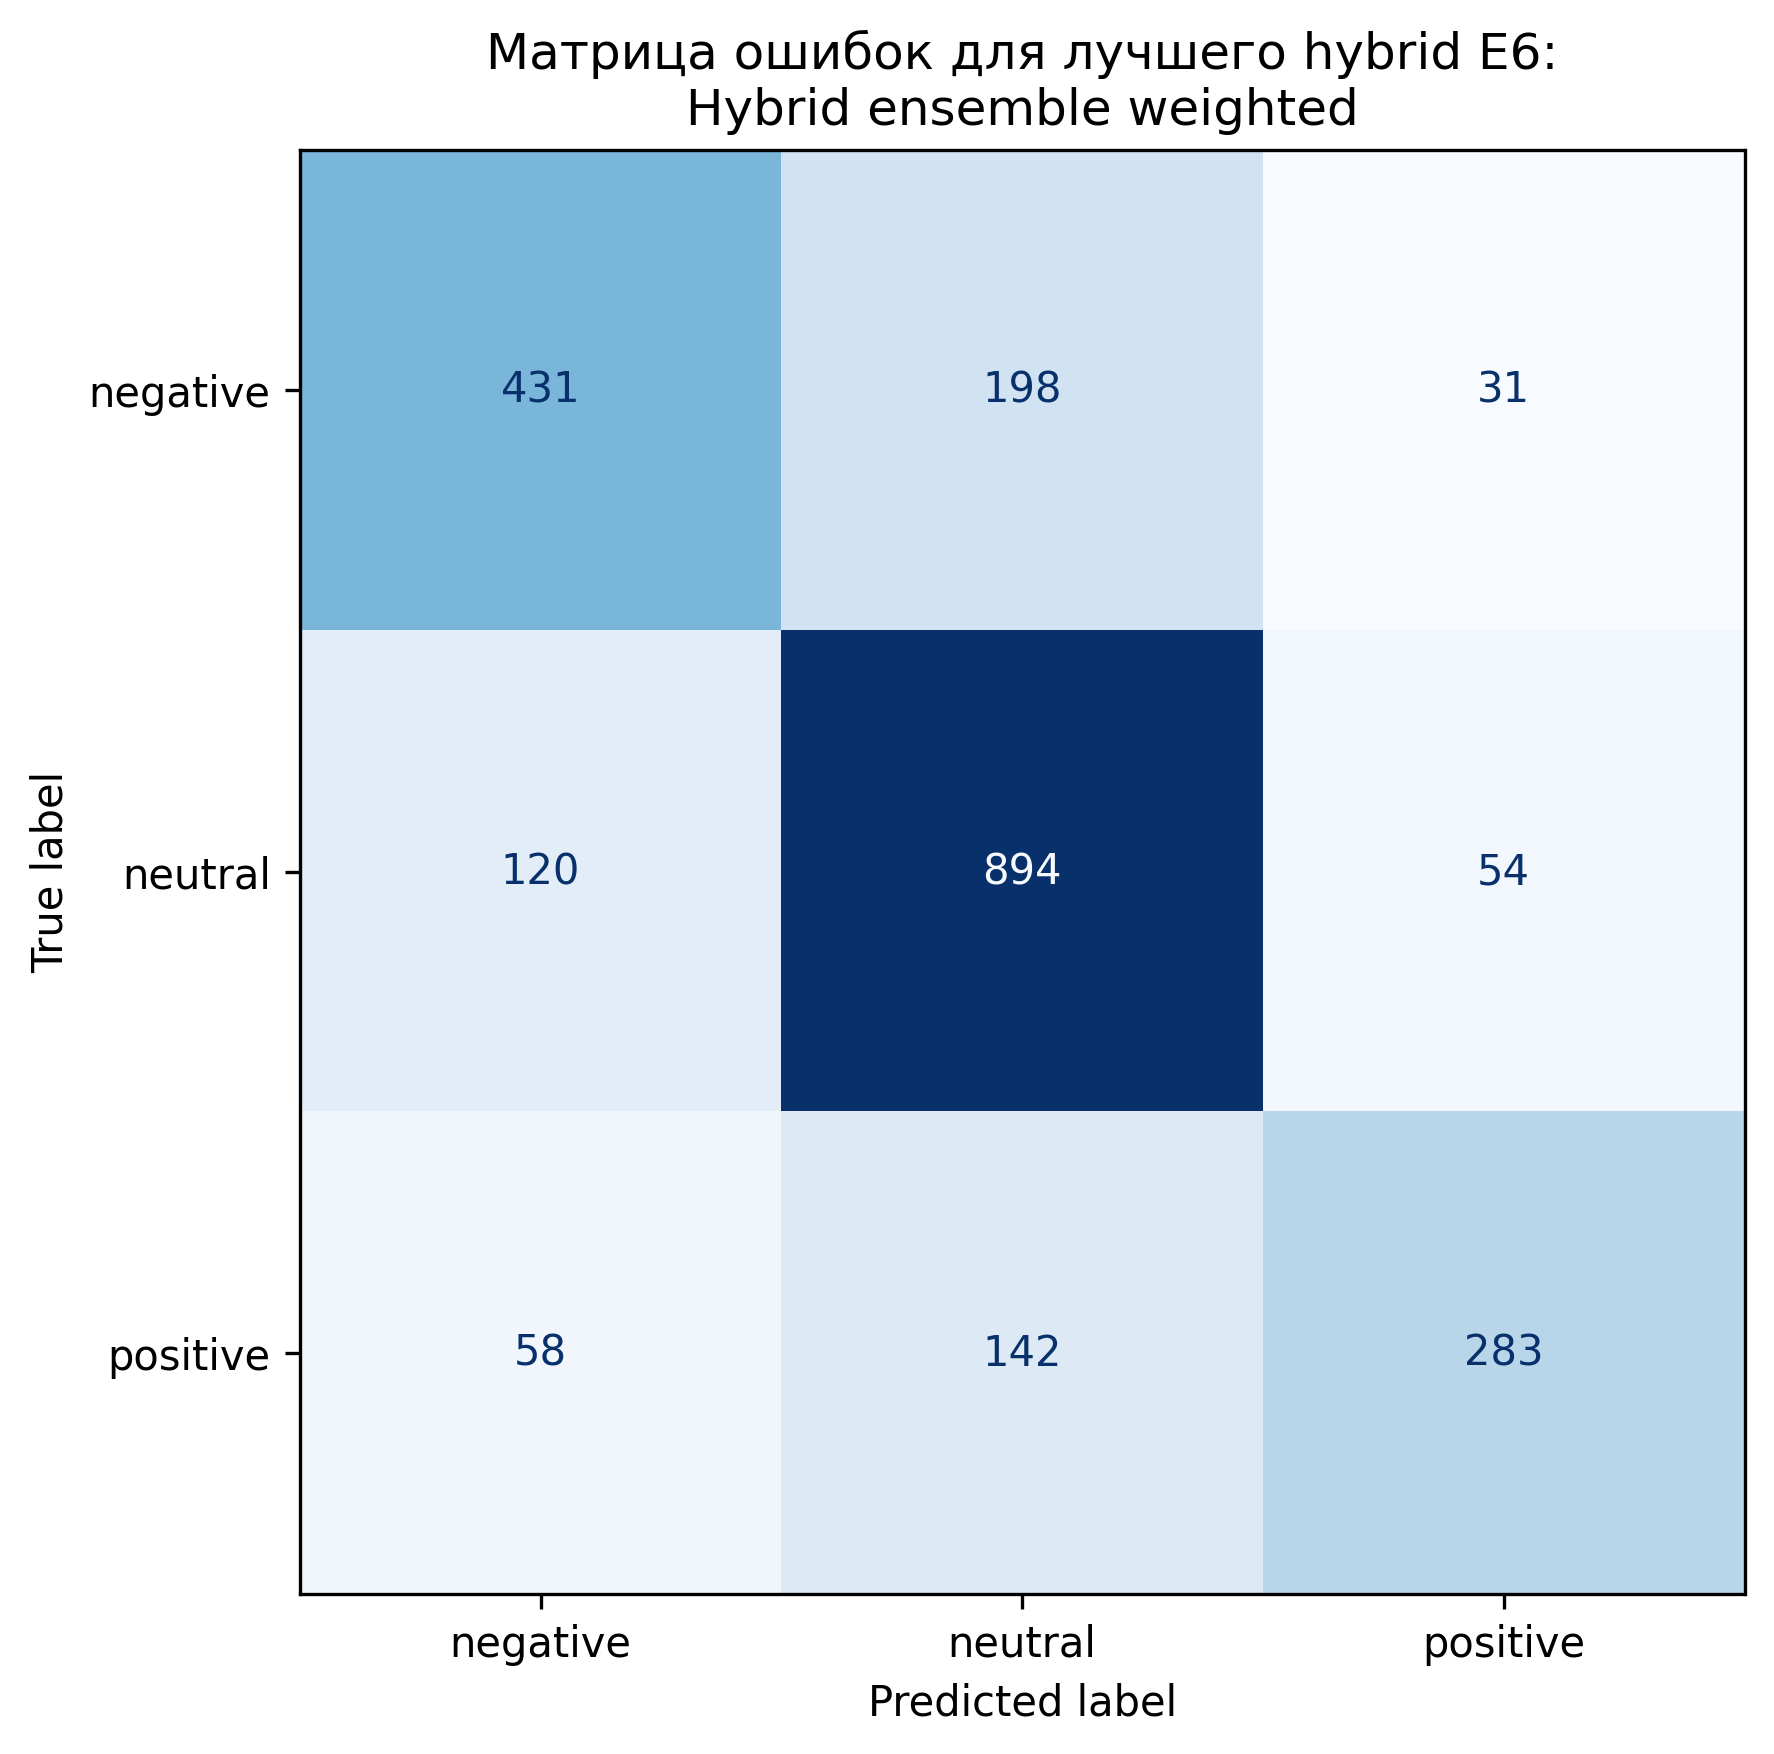

In [35]:
labels_order = ["negative", "neutral", "positive"]

cm_best_e6 = confusion_matrix(y_test, best_e6_pred, labels=labels_order)
disp_best_e6 = ConfusionMatrixDisplay(confusion_matrix=cm_best_e6, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_best_e6.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Матрица ошибок для лучшего hybrid E6:\n{best_e6_hybrid_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "e6_best_hybrid_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
experiment_ids = [f"E6-{i+1}" for i in range(len(e6_results_df))]

e6_registry = e6_results_df.copy()
e6_registry.insert(0, "experiment_id", experiment_ids)
e6_registry["dataset"] = "RuSentiTweet"
e6_registry["train_split"] = "train_final"
e6_registry["val_split"] = "val_final"
e6_registry["test_split"] = "test_final"
e6_registry["status"] = "completed"

display(e6_registry)

,experiment_id,model,ensemble_type,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,extra_time_sec,seed,dataset,train_split,val_split,test_split,status
0,E6-1,Hybrid ensemble weighted,soft_voting_weighted_by_val,0.7273,0.7292,0.7273,0.7232,0.7070,63.8727,42,RuSentiTweet,train_final,val_final,test_final,completed
1,E6-2,Hybrid ensemble equal,soft_voting_equal,0.7259,0.7280,0.7259,0.7218,0.7053,63.8727,42,RuSentiTweet,train_final,val_final,test_final,completed
2,E6-3,Standalone BERT tuned,reference_test,0.6970,0.6956,0.6970,0.6958,0.6808,60.6938,42,RuSentiTweet,train_final,val_final,test_final,completed
3,E6-4,Standalone classical,reference_test,0.6762,0.6804,0.6762,0.6668,0.6424,3.1789,42,RuSentiTweet,train_final,val_final,test_final,completed


In [37]:
e6_registry.to_csv(TABLE_DIR / "e6_experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e6_experiment_registry.csv")

Saved: e6_artifacts/tables/e6_experiment_registry.csv


In [38]:
standalone_classical_wf1 = e6_results_df[e6_results_df["model"] == "Standalone classical"]["weighted_f1"].iloc[0]
standalone_bert_wf1 = e6_results_df[e6_results_df["model"] == "Standalone BERT tuned"]["weighted_f1"].iloc[0]
best_hybrid_wf1 = hybrid_only_df.iloc[0]["weighted_f1"]

delta_vs_classical = round(best_hybrid_wf1 - standalone_classical_wf1, 4)
delta_vs_bert = round(best_hybrid_wf1 - standalone_bert_wf1, 4)

e6_summary = f"""
E6 HYBRID ENSEMBLE SUMMARY

Goal:
Evaluate whether hybrid ensemble of the best classical model and tuned BERT
improves performance.

Dataset:
RuSentiTweet

Train shape:
{train_df.shape}

Validation shape:
{val_df.shape}

Test shape:
{test_df.shape}

Classical component:
SGDClassifier hinge + char TF-IDF (3,5) + calibration

BERT component:
ruBERT-tiny2 tuned

Validation-based weights:
classical = {weights[0]:.4f}
bert = {weights[1]:.4f}

Best hybrid:
{best_e6_hybrid_name}

Best hybrid weighted_f1:
{best_hybrid_wf1}

Standalone classical weighted_f1:
{standalone_classical_wf1}

Standalone BERT weighted_f1:
{standalone_bert_wf1}

Delta vs standalone classical:
{delta_vs_classical}

Delta vs standalone BERT:
{delta_vs_bert}

Full ranking:
{e6_results_df[["model", "ensemble_type", "weighted_f1", "macro_f1"]].to_string(index=False)}
"""

with open(LOG_DIR / "e6_summary.txt", "w", encoding="utf-8") as f:
    f.write(e6_summary)

print("Saved:", LOG_DIR / "e6_summary.txt")

Saved: e6_artifacts/logs/e6_summary.txt
